Подготовка данных. Импорт zip архива.

In [ ]:
import os
import zipfile
import requests

def unzip_to_colab(zip_file_path, extract_path=None, delete_zip=False):

    try:
        # 1. Проверка файла
        if not os.path.exists(zip_file_path):
            print(f"Error: File '{zip_file_path}' not found.")
            return

        # 2. Путь
        if extract_path is None:
            extract_path = os.getcwd()  # Текущая директория
        else:
            # Создать директорию, если ее нет
            os.makedirs(extract_path, exist_ok=True)


        # 3. Распаковка
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)

        print(f"Zip archive '{zip_file_path}' successfully extracted to '{extract_path}'.")

        # 4. Delete the zip file (if specified)
        if delete_zip:
            try:
                os.remove(zip_file_path)
                print(f"Zip file '{zip_file_path}' deleted.")
            except OSError as e:
                print(f"Error deleting zip file: {e}")


    except zipfile.BadZipFile as e:
        print(f"Error: File '{zip_file_path}' is not a valid zip archive. Error: {e}")
    except FileNotFoundError as e:
        print(f"Error: File '{zip_file_path}' not found. Error: {e}")
    except Exception as e:
        print(f"An error occurred during extraction: {e}")


def download_and_save(url, save_path):
    """
    Загрузка файла с URL и сохранение его.
    """
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status()

        with open(save_path, 'wb') as file:
            for chunk in response.iter_content(chunk_size=8192):
                file.write(chunk)
        print(f"File successfully downloaded and saved to: {save_path}")

    except requests.exceptions.RequestException as e:
        print(f"Error downloading file from '{url}': {e}")
        return False  # Indicate failure
    except Exception as e:
        print(f"An error occurred while downloading and saving the file: {e}")
        return False  # Indicate failure
    return True # Indicate success

In [ ]:
zip_file_path = '/content/sample_data/dataset.zip'
extract_path = '/content/sample_data'
unzip_to_colab(zip_file_path, extract_path)


Zip archive '/content/sample_data/dataset.zip' successfully extracted to '/content/sample_data'.


Разбивка данных на тренировочные и тестовые

In [ ]:
import os
import random
import shutil

# 1. Определите пути и параметры
DATA_DIR = '/content/sample_data'  # Каталог с папками классов
TRAIN_DIR = '/content/train'      # Каталог для тренировочной выборки
TEST_DIR = '/content/test'        # Каталог для тестовой выборки
SPLIT_RATIO = 0.8                 # Соотношение тренировочной и тестовой выборки
RANDOM_SEED = 42                   # Для воспроизводимости результатов

# 2. Создание целевых каталогов
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

# 3. Для воспроизводимости
random.seed(RANDOM_SEED)

# 4. Получите список классов (подпапок в DATA_DIR)
classes = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
print(f"Обнаружены классы: {classes}")

# 5. Разделите данные для каждого класса
for class_name in classes:
    class_dir = os.path.join(DATA_DIR, class_name)
    images = os.listdir(class_dir)
    num_images = len(images)
    num_train = int(num_images * SPLIT_RATIO)

    # Перемешайте список файлов
    random.shuffle(images)

    # Разделите на тренировочную и тестовую выборки
    train_images = images[:num_train]
    test_images = images[num_train:]

    # 6. Создайте папки классов в тренировочном и тестовом каталогах
    train_class_dir = os.path.join(TRAIN_DIR, class_name)
    test_class_dir = os.path.join(TEST_DIR, class_name)
    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(test_class_dir, exist_ok=True)

    # 7. Переместите файлы в соответствующие папки
    for image in train_images:
        src_path = os.path.join(class_dir, image)
        dst_path = os.path.join(train_class_dir, image)
        shutil.copyfile(src_path, dst_path)  # copyfile, чтобы не удалять файлы из исходной папки
        #os.rename(src_path, dst_path) #Если нужно переместить а не копировать файлы раскомментируйте эту строку и закоментируйте shutil.copyfile

    for image in test_images:
        src_path = os.path.join(class_dir, image)
        dst_path = os.path.join(test_class_dir, image)
        shutil.copyfile(src_path, dst_path)  # Используйте copyfile, чтобы не удалять файлы из исходной папки
        #os.rename(src_path, dst_path) #Если нужно переместить а не копировать файлы раскомментируйте эту строку и закоментируйте shutil.copyfile
    # 8. Выведите статистику
    print(f"Класс: {class_name}")
    print(f"  Всего изображений: {num_images}")
    print(f"  Тренировочных изображений: {len(train_images)}")
    print(f"  Тестовых изображений: {len(test_images)}")

print("Разделение данных завершено.")


Обнаружены классы: ['nodefects', 'scratch', 'pores', 'label', 'attrition']
Класс: nodefects
  Всего изображений: 134
  Тренировочных изображений: 107
  Тестовых изображений: 27
Класс: scratch
  Всего изображений: 451
  Тренировочных изображений: 360
  Тестовых изображений: 91
Класс: pores
  Всего изображений: 360
  Тренировочных изображений: 288
  Тестовых изображений: 72
Класс: label
  Всего изображений: 474
  Тренировочных изображений: 379
  Тестовых изображений: 95
Класс: attrition
  Всего изображений: 791
  Тренировочных изображений: 632
  Тестовых изображений: 159
Разделение данных завершено.


Вывод информации об образце из DataGeneration


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
image_path = '/content/train/attrition/def11.jpg'

img = mpimg.imread(image_path)

plt.imshow(img)
plt.axis('off')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/train/attrition/def11.jpg'

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
img_width, img_height = 224, 224  # Размер изображений
batch_size = 16   # Размер батча
train_dir = '/content/train'  # Путь к тренировочным данным
val_dir = '/content/test'  # Путь к валидационным данным
#Создайте экземпляры двух классов генераторов изображений:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,        # случайные повороты на +-30 градусов
    horizontal_flip=True,     # случайное отражение по горизонтали
    fill_mode='reflect',       # заполнение пустых мест отражением краёв
    validation_split=0.2
)

valid_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(224, 224),
    classes=['attrition', 'label', 'nodefects', 'pores', 'scratch'],
    color_mode = 'grayscale',
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    )

valid_generator = valid_datagen.flow_from_directory(
    directory=val_dir,
    target_size=(224, 224),
    classes=['attrition', 'label', 'nodefects', 'pores', 'scratch'],
    color_mode = 'grayscale',
    class_mode='categorical',
    batch_size=batch_size,
    )
# Проверяем форму первого пакета
x_batch, y_batch = next(train_generator)
print("Shape of x_batch:", x_batch.shape)  # Должно быть (batch_size, 224, 224, num_channels)
x_batch, y_batch = next(valid_generator)
print("Shape of x_batch:", x_batch.shape)

Found 1766 images belonging to 5 classes.
Found 444 images belonging to 5 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:146: UserWarning: Using ".tiff" files with multiple bands will cause distortion. Please verify your output.
  warnings.warn(


Shape of x_batch: (16, 224, 224, 1)
Shape of x_batch: (16, 224, 224, 1)


In [ ]:
data_batch, labels_batch = train_generator.__next__()
# Проверка классов
print("Классы:", train_generator.class_indices)
# Вывод информации о пакете
print("Размер пакета изображений (data_batch.shape):", data_batch.shape)  # (batch_size, img_width, img_height, channels)
print("Размер пакета меток (labels_batch.shape):", labels_batch.shape)  # (batch_size,)  (или (batch_size, num_classes) для categorical)
print("Тип данных изображений (data_batch.dtype):", data_batch.dtype)
print("Тип данных меток (labels_batch.dtype):", labels_batch.dtype)
print("Метки в пакете (labels_batch):", labels_batch)  # Вывод меток

# Вывод информации о генераторе
print("\nАтрибуты train_generator:")
print("  .directory:", train_generator.directory)  # Корневой каталог
print("  .image_shape:", train_generator.image_shape)  # Размеры изображения (высота, ширина, каналы)
print("  .num_classes:", train_generator.num_classes)  # Количество классов
print("  .class_indices:", train_generator.class_indices)  # Словарь сопоставления имен классов с индексами
print("  .samples:", train_generator.samples)  # Общее количество образцов
print("  .batch_size:", train_generator.batch_size)  # Размер пакета
print("  .target_size:", train_generator.target_size)  # Целевой размер изображения
print("  .color_mode:", train_generator.color_mode)  # Цветовой режим
print("  .class_mode:", train_generator.class_mode)  # Режим классов
print("  .shuffle:", train_generator.shuffle)  # Перемешивание

Классы: {'attrition': 0, 'label': 1, 'nodefects': 2, 'pores': 3, 'scratch': 4}
Размер пакета изображений (data_batch.shape): (16, 224, 224, 1)
Размер пакета меток (labels_batch.shape): (16, 5)
Тип данных изображений (data_batch.dtype): float32
Тип данных меток (labels_batch.dtype): float32
Метки в пакете (labels_batch): [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]]

Атрибуты train_generator:
  .directory: /content/train
  .image_shape: (224, 224, 1)
  .num_classes: 5
  .class_indices: {'attrition': 0, 'label': 1, 'nodefects': 2, 'pores': 3, 'scratch': 4}
  .samples: 1766
  .batch_size: 16
  .target_size: (224, 224)
  .color_mode: grayscale
  .class_mode: categorical
  .shuffle: True


In [ ]:
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
# Создание модели классификации
model = Sequential(),
inputs = Input(shape=(224, 224, 1))
x = Conv2D(32, 3, activation="relu", padding="same")(inputs)
x = MaxPooling2D(pool_size=2)(x)
x = Conv2D(64, 3, activation="relu", padding="same")(x)
#x = MaxPooling2D(pool_size=2)(x)
x = Flatten()(x)
x = Dense(64, activation="relu")(x)

    # Выход: [x, y, width, height, class_id]
output = Dense(5, activation="softmax")(x)
model = tf.keras.Model(inputs, output)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 802816)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │    51,380,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,399,429 (196.07 MB)

 Trainable params: 51,399,429 (196.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
history = model.fit(train_generator, epochs=10, batch_size=8, validation_data=valid_generator, callbacks=[checkpoint])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.4625 - loss: 1.8319

111/111 ━━━━━━━━━━━━━━━━━━━━ 34s 245ms/step - accuracy: 0.4637 - loss: 1.8263 - val_accuracy: 0.7410 - val_loss: 0.8086
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.7865 - loss: 0.6577

111/111 ━━━━━━━━━━━━━━━━━━━━ 28s 181ms/step - accuracy: 0.7865 - loss: 0.6576 - val_accuracy: 0.8311 - val_loss: 0.5054
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8602 - loss: 0.4488

111/111 ━━━━━━━━━━━━━━━━━━━━ 17s 149ms/step - accuracy: 0.8603 - loss: 0.4487 - val_accuracy: 0.8739 - val_loss: 0.4230
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8451 - loss: 0.4299

111/111 ━━━━━━━━━━━━━━━━━━━━ 19s 171ms/step - accuracy: 0.8451 - loss: 0.4297 - val_accuracy: 0.8536 - val_loss: 0.3917
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8525 - loss: 0.4178

111/111 ━━━━━━━━━━━━━━━━━━━━ 19s 176ms/step - accuracy: 0.8527 - loss: 0.4174 - val_accuracy: 0.8829 - val_loss: 0.3201
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 15s 130ms/step - accuracy: 0.8980 - loss: 0.3151 - val_accuracy: 0.8986 - val_loss: 0.3678
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 16s 142ms/step - accuracy: 0.9099 - loss: 0.2466 - val_accuracy: 0.9009 - val_loss: 0.3499
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9227 - loss: 0.2016

111/111 ━━━━━━━━━━━━━━━━━━━━ 17s 150ms/step - accuracy: 0.9226 - loss: 0.2018 - val_accuracy: 0.9167 - val_loss: 0.2329
Epoch 9/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 14s 130ms/step - accuracy: 0.9199 - loss: 0.2059 - val_accuracy: 0.8941 - val_loss: 0.4600
Epoch 10/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 14s 129ms/step - accuracy: 0.9377 - loss: 0.1702 - val_accuracy: 0.8964 - val_loss: 0.2779


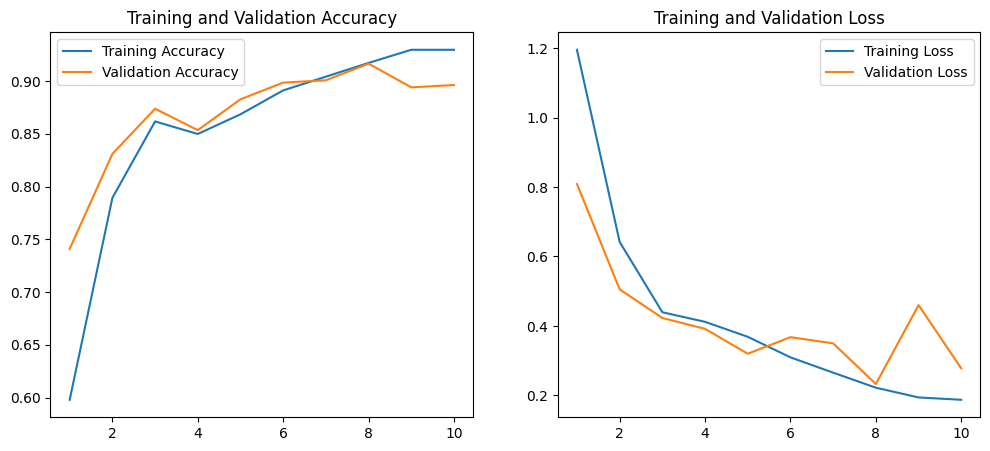

In [ ]:
# history = model.fit(
#     train_generator,
#     steps_per_epoch=train_generator.samples // batch_size,
#     epochs=epochs,
#     validation_data=valid_generator,
#     validation_steps=valid_generator.samples // batch_size)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()


In [ ]:
# Оценка модели на тестовых данных
valid_generator = valid_datagen.flow_from_directory(
    directory=val_dir,
    target_size=(224, 224),
    classes=['attrition', 'label', 'nodefects', 'pores', 'scratch'],
    color_mode = 'grayscale',
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False  # Важно для правильного вычисления метрик
)

Found 444 images belonging to 5 classes.


In [ ]:
print(len(valid_generator.classes))
print(valid_generator.class_indices)

444
{'attrition': 0, 'label': 1, 'nodefects': 2, 'pores': 3, 'scratch': 4}


In [ ]:
 print(np.unique(classes))

['attrition' 'label' 'nodefects' 'pores' 'scratch']


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

# 1. Получение предсказаний от модели
predictions = model.predict(valid_generator)

# 2. Получение истинных меток (ground truth) из val_generator

true_classes = valid_generator.classes  # Если это DirectoryIterator

# 3. Преобразование вероятностей в классы (если модель предсказывает вероятности)

predicted_classes = np.argmax(predictions, axis=1)

# 4. Вычисление accuracy
accuracy = accuracy_score(true_classes, predicted_classes)

# 5. Вывод метрики
print(f"Accuracy: {accuracy}")

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
Accuracy: 0.8963963963963963


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Вариант 1: Расчет метрик для каждого класса отдельно (average=None)
precision = precision_score(true_classes, predicted_classes, average=None)
recall = recall_score(true_classes, predicted_classes, average=None)
f1 = f1_score(true_classes, predicted_classes, average=None)

print("Precision per class:", precision)
print("Recall per class:", recall)
print("F1-score per class:", f1)

# Общие метрики и отчет о классификации (рекомендуется использовать classification_report)
conf_matrix = confusion_matrix(true_classes, predicted_classes)  # Матрица ошибок
class_report = classification_report(true_classes, predicted_classes) # Отчет о классификации

print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)


Precision per class: [0.99295775 0.95959596 0.88888889 0.78947368 0.78899083]
Recall per class: [0.88679245 1.         0.59259259 0.83333333 0.94505495]
F1-score per class: [0.93687708 0.97938144 0.71111111 0.81081081 0.86      ]
Confusion Matrix:
 [[141   0   1   7  10]
 [  0  95   0   0   0]
 [  0   1  16   6   4]
 [  1   1   1  60   9]
 [  0   2   0   3  86]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.89      0.94       159
           1       0.96      1.00      0.98        95
           2       0.89      0.59      0.71        27
           3       0.79      0.83      0.81        72
           4       0.79      0.95      0.86        91

    accuracy                           0.90       444
   macro avg       0.88      0.85      0.86       444
weighted avg       0.90      0.90      0.90       444



In [ ]:
true_classes = valid_generator.classes

print("Class Indices:", valid_generator.class_indices)

Class Indices: {'attrition': 0, 'label': 1, 'nodefects': 2, 'pores': 3, 'scratch': 4}


In [ ]:
classes = ['attrition', 'label', 'nodefects', 'pores', 'scratch']

Accuracy: 0.8963963963963963
Precision per class: [0.99295775 0.95959596 0.88888889 0.78947368 0.78899083]
Recall per class: [0.88679245 1.         0.59259259 0.83333333 0.94505495]
F1-score per class: [0.93687708 0.97938144 0.71111111 0.81081081 0.86      ]
Confusion Matrix:
 [[141   0   1   7  10]
 [  0  95   0   0   0]
 [  0   1  16   6   4]
 [  1   1   1  60   9]
 [  0   2   0   3  86]]
Classification Report:
               precision    recall  f1-score   support

   attrition       0.99      0.89      0.94       159
       label       0.96      1.00      0.98        95
   nodefects       0.89      0.59      0.71        27
       pores       0.79      0.83      0.81        72
     scratch       0.79      0.95      0.86        91

    accuracy                           0.90       444
   macro avg       0.88      0.85      0.86       444
weighted avg       0.90      0.90      0.90       444



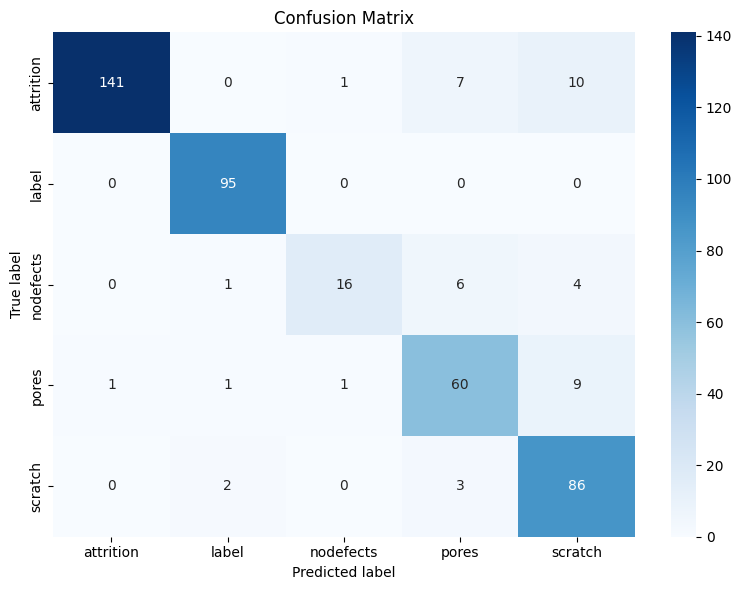

In [ ]:
import seaborn as sns
def plot_confusion_matrix(true_classes, predicted_classes, classes, title='Confusion Matrix', cmap='Blues'):  # classes теперь обязательный аргумент
    cm = confusion_matrix(true_classes, predicted_classes)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

# 6. Вывод метрик
accuracy = accuracy_score(true_classes, predicted_classes)
print(f"Accuracy: {accuracy}")

precision = precision_score(true_classes, predicted_classes, average=None)
recall = recall_score(true_classes, predicted_classes, average=None)
f1 = f1_score(true_classes, predicted_classes, average=None)

print("Precision per class:", precision)
print("Recall per class:", recall)
print("F1-score per class:", f1)

conf_matrix = confusion_matrix(true_classes, predicted_classes)
class_report = classification_report(true_classes, predicted_classes, target_names=classes) # Указываем target_names

print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

# 7. Вывод матрицы соответствия (ОБЯЗАТЕЛЬНО передаем список classes)
plot_confusion_matrix(true_classes, predicted_classes, classes=classes, title='Confusion Matrix', cmap='Blues')

Увеличиваемт количество изображений в обучающем наборе за счёт аугментации.
Нормализуем пиксели: преобразуем значения в диапазон [0,1].
Создаём генераторы данных: train_generator и val_generator.

In [ ]:
import os
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from PIL import Image
import matplotlib.pyplot as plt
from keras.optimizers import Adam

In [ ]:
  !pip install opencv-python tqdm

Код пройдет по всем изображениям в grayscale, преобразует их в RGB и сохранит в соответствующие папки в указанных выходных директориях. tqdm будет показывать прогресс преобразования.
1. Импортирует необходимые библиотеки:
  - os: Для работы с файловой системой (создание папок, перечисление файлов).
  - cv2: OpenCV (cv2) для чтения и записи изображений, а также для преобразования цветовых пространств.
  - numpy: Для работы с массивами (изображения представляются как массивы).
  - tqdm: Для отображения прогресс-бара.
2. Функция grayscale_to_rgb(input_dir, output_dir):
  - Принимает пути к входной и выходной папкам.
  - Проверяет существование входной папки.
  - Создает выходную папку (и подпапки классов), если она не существует.
  - Перебирает подпапки (классы) во входной папке.
  - Перебирает файлы изображений в каждой папке класса.
  - Для каждого изображения:
   - Читает изображение в grayscale с помощью cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).
   - Преобразует grayscale изображение в RGB с помощью cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB).
   - Сохраняет RGB изображение с помощью cv2.imwrite(output_path, img_rgb).
  - Обрабатывает исключения (ошибки при чтении или записи изображений).


In [ ]:
import os

def create_directory(directory_path):
    """Создает директорию, если она еще не существует.

    Args:
        directory_path (str): Путь к директории, которую нужно создать.
    """
    if not os.path.exists(directory_path):
        try:
            os.makedirs(directory_path)
            print(f"Директория '{directory_path}' успешно создана.")
        except OSError as e:
            print(f"Ошибка при создании директории '{directory_path}': {e}")
    else:
        print(f"Директория '{directory_path}' уже существует.")

# Определяем пути для папок
train_grayscale_path = "train_rgb_images"
test_rgb_path = "test_rgb_images"

# Создаем папки
create_directory(train_grayscale_path)
create_directory(test_rgb_path)

print("Готово.")

Директория 'train_rgb_images' успешно создана.
Директория 'test_rgb_images' успешно создана.
Готово.


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm  # Для отображения прогресса

def grayscale_to_rgb(input_dir, output_dir):
    """
    Преобразует изображения в grayscale в RGB формат, сохраняя структуру папок.
    Args:
        input_dir (str): Путь к папке с изображениями в grayscale, рассортированными по классам.
                         Структура должна быть: input_dir/класс1/изображения, input_dir/класс2/изображения, ...
        output_dir (str): Путь к папке, где будут сохранены преобразованные изображения в RGB.
                          Будет создана аналогичная структура папок.
    """

    # Проверяем, существует ли входная папка
    if not os.path.exists(input_dir):
        print(f"Ошибка: Входная папка '{input_dir}' не существует.")
        return

    # Создаем выходную папку, если она не существует
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Получаем список классов (подпапок) во входной папке
    classes = os.listdir(input_dir)
    print(f"Найдены классы: {classes}")

    for class_name in classes:
        class_input_dir = os.path.join(input_dir, class_name)
        class_output_dir = os.path.join(output_dir, class_name)

        # Проверяем, что это действительно папка
        if not os.path.isdir(class_input_dir):
            print(f"Предупреждение: '{class_input_dir}' не является папкой. Пропускаем.")
            continue

        # Создаем папку класса в выходной папке
        if not os.path.exists(class_output_dir):
            os.makedirs(class_output_dir)

        # Получаем список файлов изображений в папке класса
        image_files = os.listdir(class_input_dir)

        print(f"Обработка класса: {class_name}")
        for image_file in tqdm(image_files, desc=f"Преобразование изображений в {class_name}"):
            image_path = os.path.join(class_input_dir, image_file)
            output_path = os.path.join(class_output_dir, image_file)

            try:
                # Читаем изображение в grayscale
                img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

                # Проверяем, успешно ли прочитано изображение
                if img_gray is None:
                    print(f"Ошибка: Не удалось прочитать изображение '{image_path}'. Пропускаем.")
                    continue

                # Преобразуем в RGB
                img_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)

                # Сохраняем изображение в RGB
                cv2.imwrite(output_path, img_rgb)

            except Exception as e:
                print(f"Ошибка при обработке изображения '{image_path}': {e}. Пропускаем.")




In [ ]:
# Запуск преобразования
train_input_dir = "/content/train"  # Замените на путь к вашей папке train
train_output_dir = "/content/train_rgb_images"  # Замените на путь, куда сохранить train RGB
test_input_dir = "/content/test"  # Замените на путь к вашей папке test
test_output_dir = "/content/test_rgb_images"  # Замените на путь, куда сохранить test RGB

grayscale_to_rgb(train_input_dir, train_output_dir)
grayscale_to_rgb(test_input_dir, test_output_dir)

print("Преобразование завершено.")


Найдены классы: ['nodefects', 'scratch', 'pores', 'label', 'attrition']
Обработка класса: nodefects


Преобразование изображений в nodefects: 100%|██████████| 107/107 [00:04<00:00, 22.74it/s]


Обработка класса: scratch


Преобразование изображений в scratch: 100%|██████████| 360/360 [00:02<00:00, 128.54it/s]


Обработка класса: pores


...

Обработка класса: label


Преобразование изображений в label: 100%|██████████| 95/95 [00:00<00:00, 290.25it/s]


Обработка класса: attrition


Преобразование изображений в attrition: 100%|██████████| 159/159 [00:00<00:00, 297.25it/s]

Преобразование завершено.



Загрузка обученной модели.

In [ ]:
img_width, img_height = 224, 224  # Размер изображений
batch_size = 16   # Размер батча
train_dir = '/content/train_rgb_images'  # Путь к тренировочным данным
val_dir = '/content/test_rgb_images'  # Путь к валидационным данным
#Создайте экземпляры двух классов генераторов изображений:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,     # случайное отражение по горизонтали
    fill_mode='reflect',       # заполнение пустых мест отражением краёв
    validation_split=0.2
)

valid_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(224, 224),
    classes=['attrition', 'label', 'nodefects', 'pores', 'scratch'],
    color_mode = 'rgb',
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    )

valid_generator = valid_datagen.flow_from_directory(
    directory=val_dir,
    target_size=(224, 224),
    classes=['attrition', 'label', 'nodefects', 'pores', 'scratch'],
    color_mode = 'rgb',
    class_mode='categorical',
    batch_size=batch_size,
    )
# Проверяем форму первого пакета
x_batch, y_batch = next(train_generator)
print("Shape of x_batch:", x_batch.shape)  # Должно быть (batch_size, 224, 224, num_channels)
x_batch, y_batch = next(valid_generator)
print("Shape of x_batch:", x_batch.shape)

Found 1766 images belonging to 5 classes.
Found 444 images belonging to 5 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:146: UserWarning: Using ".tiff" files with multiple bands will cause distortion. Please verify your output.
  warnings.warn(


Shape of x_batch: (16, 224, 224, 3)
Shape of x_batch: (16, 224, 224, 3)


In [ ]:
# # Загрузка модели
# import keras
# from tensorflow.keras.applications import VGG19
# from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
# from tensorflow.keras.models import Model
from tensorflow.keras.initializers import HeNormal
base_model = VGG19 (include_top=False, weights='imagenet', input_shape=(224, 224, 3))

base_model.summary()

for layer in base_model.layers:
    layer.trainable = False
# Добавление своих классифицирующих слоев (поверх VGG19)

# flattened превращает выходы сверточных слоев в одномерный вектор как в прошлой работе

# Преобразуем двумерные данные в вектор
keras.layers.Flatten(),

# Instantiate the sequential model and add the model:
model = Sequential()
model.add(base_model)

# Add the custom layers atop the model:
model.add(Flatten(name='flattened'))
model.add(Dropout(0.5))
model.add(Dense(64,
                activation='relu',
                kernel_initializer=HeNormal()))
model.add(Dropout(0.7))
model.add(Dense(5, activation='softmax', kernel_regularizer=l2(0.02), name='predictions'))
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
# model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])


Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# # import tensorflow as tf
# # from tensorflow.keras.preprocessing.image import ImageDataGenerator
# # from tensorflow.keras.applications import VGG19
# from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Flatten, Dropout
# # from tensorflow.keras.models import Model, Sequential
# # from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.regularizers import l2
# from sklearn.metrics import accuracy_score
# import numpy as np

# img_width, img_height = 224, 224
# batch_size = 16
# epochs = 20
# train_dir = '/content/test_rgb_images' # Замените
# val_dir = '/content/test_rgb_images'     # Замените
# num_classes = 5 # Замените

# base_model = VGG19(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))
# base_model.trainable = False # Замораживаем веса базовой модели

# model = Sequential()
# model.add(base_model)
# model.add(Flatten(name='flattened'))
# model.add(Dropout(0.5))
# model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(32, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.01), name='predictions'))

# model.compile(optimizer=Adam(learning_rate=0.0001),
#               loss='categorical_crossentropy', metrics=['accuracy'])



In [ ]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flattened (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,630,405 (82.51 MB)

 Trainable params: 1,606,021 (6.13 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
# Проверка количества данных и batch_size
print("Number of training samples:", train_generator.samples)
print("Number of validation samples:", valid_generator.samples)
print("Batch size:", batch_size)

# Проверка наличия классов
print("Training class indices:", train_generator.class_indices)
print("Validation class indices:", valid_generator.class_indices)

# Вычисление steps_per_epoch и validation_steps (округление вверх)
steps_per_epoch = max(1, train_generator.samples // batch_size) # Убедитесь, что steps_per_epoch > 0
validation_steps = max(1, valid_generator.samples // batch_size) # Убедитесь, что validation_steps > 0

Number of training samples: 1766
Number of validation samples: 444
Batch size: 16
Training class indices: {'attrition': 0, 'label': 1, 'nodefects': 2, 'pores': 3, 'scratch': 4}
Validation class indices: {'attrition': 0, 'label': 1, 'nodefects': 2, 'pores': 3, 'scratch': 4}


In [ ]:
checkpoint = ModelCheckpoint('best_model_VG.h5', monitor='val_loss', save_best_only=True)
history = model.fit(train_generator, epochs=20, batch_size=16, validation_data=valid_generator, callbacks=[checkpoint])

Epoch 1/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.2752 - loss: 2.0233

111/111 ━━━━━━━━━━━━━━━━━━━━ 45s 367ms/step - accuracy: 0.2755 - loss: 2.0215 - val_accuracy: 0.3581 - val_loss: 1.6216
Epoch 2/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.3487 - loss: 1.6954

111/111 ━━━━━━━━━━━━━━━━━━━━ 37s 338ms/step - accuracy: 0.3488 - loss: 1.6953 - val_accuracy: 0.4144 - val_loss: 1.5473
Epoch 3/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.3636 - loss: 1.6182

111/111 ━━━━━━━━━━━━━━━━━━━━ 37s 336ms/step - accuracy: 0.3638 - loss: 1.6182 - val_accuracy: 0.7973 - val_loss: 1.4659
Epoch 4/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.4206 - loss: 1.5555

111/111 ━━━━━━━━━━━━━━━━━━━━ 37s 332ms/step - accuracy: 0.4207 - loss: 1.5552 - val_accuracy: 0.7455 - val_loss: 1.3038
Epoch 5/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.4378 - loss: 1.4952

...

111/111 ━━━━━━━━━━━━━━━━━━━━ 37s 337ms/step - accuracy: 0.5688 - loss: 1.1538 - val_accuracy: 0.8333 - val_loss: 0.7550
Epoch 16/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 36s 327ms/step - accuracy: 0.5873 - loss: 1.0978 - val_accuracy: 0.8266 - val_loss: 0.7574
Epoch 17/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.5991 - loss: 1.0633

111/111 ━━━━━━━━━━━━━━━━━━━━ 37s 334ms/step - accuracy: 0.5990 - loss: 1.0634 - val_accuracy: 0.8266 - val_loss: 0.7236
Epoch 18/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.6026 - loss: 1.0472

111/111 ━━━━━━━━━━━━━━━━━━━━ 36s 319ms/step - accuracy: 0.6026 - loss: 1.0473 - val_accuracy: 0.8491 - val_loss: 0.7094
Epoch 19/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.6188 - loss: 1.0355

111/111 ━━━━━━━━━━━━━━━━━━━━ 37s 332ms/step - accuracy: 0.6188 - loss: 1.0355 - val_accuracy: 0.8581 - val_loss: 0.6685
Epoch 20/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.6206 - loss: 1.0343

111/111 ━━━━━━━━━━━━━━━━━━━━ 35s 312ms/step - accuracy: 0.6205 - loss: 1.0342 - val_accuracy: 0.8288 - val_loss: 0.6545


In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=valid_generator,
    validation_steps=valid_generator.samples // batch_size)


NameError: name 'model' is not defined

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()


In [ ]:
# Evaluation
# No need to redefine valid_generator here, reuse the one defined earlier
valid_generator = valid_datagen.flow_from_directory(
    directory=val_dir,
    target_size=(224, 224),
    classes=['attr', 'label', 'no', 'pores', 'scr'],
    class_mode='categorical',
    batch_size=batch_size,
    shuffle = False,
    )
predictions = model.predict(valid_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = valid_generator.classes
class_labels = list(valid_generator.class_indices.keys())

print(f"Accuracy: {accuracy_score(true_classes, predicted_classes)}")

Found 167 images belonging to 5 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step
Accuracy: 0.9640718562874252


In [ ]:
import tensorflow as tf

# Сохранение всей модели (архитектура, веса, конфигурация обучения, оптимизатор)
model.save('my_model.h5')

# Загрузка модели
loaded_model = tf.keras.models.load_model('my_model.h5')


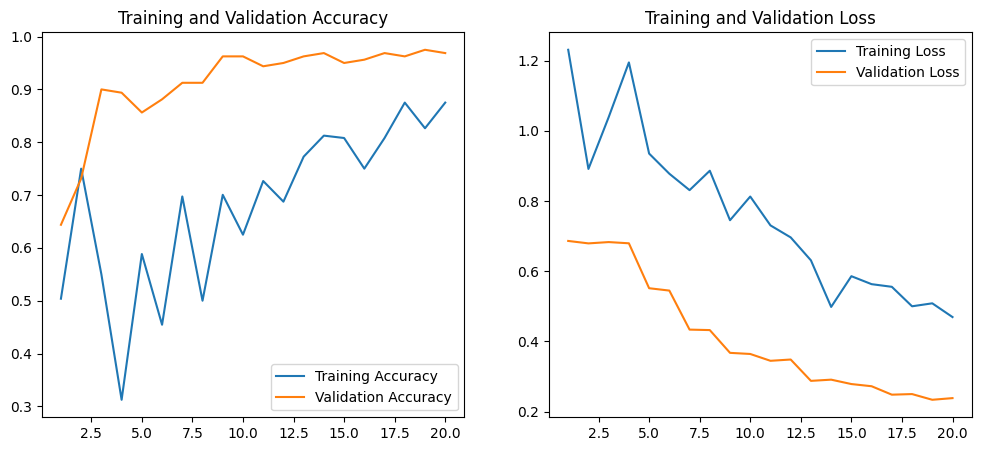

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Вариант 1: Расчет метрик для каждого класса отдельно (average=None)
precision = precision_score(true_classes, predicted_classes, average=None)
recall = recall_score(true_classes, predicted_classes, average=None)
f1 = f1_score(true_classes, predicted_classes, average=None)

print("Precision per class:", precision)
print("Recall per class:", recall)
print("F1-score per class:", f1)

# Общие метрики и отчет о классификации (рекомендуется использовать classification_report)
conf_matrix = confusion_matrix(true_classes, predicted_classes)  # Матрица ошибок
class_report = classification_report(true_classes, predicted_classes) # Отчет о классификации

print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)


Precision per class: [0.97849462 0.94594595]
Recall per class: [0.95789474 0.97222222]
F1-score per class: [0.96808511 0.95890411]
Confusion Matrix:
 [[91  4]
 [ 2 70]]
Classification Report:
               precision    recall  f1-score   support

           1       0.98      0.96      0.97        95
           3       0.95      0.97      0.96        72

    accuracy                           0.96       167
   macro avg       0.96      0.97      0.96       167
weighted avg       0.96      0.96      0.96       167



In [ ]:
# Вариант 2: Использование 'micro' усреднения (подходит, когда важен общий результат)
precision_micro = precision_score(true_classes, predicted_classes, average='micro')
recall_micro = recall_score(true_classes, predicted_classes, average='micro')
f1_micro = f1_score(true_classes, predicted_classes, average='micro')

print("Micro-averaged precision:", precision_micro)
print("Micro-averaged recall:", recall_micro)
print("Micro-averaged F1-score:", f1_micro)

Micro-averaged precision: 0.25
Micro-averaged recall: 0.25
Micro-averaged F1-score: 0.25


In [ ]:
# Вариант 3: Использование 'macro' усреднения (подходит, когда все классы одинаково важны)
precision_macro = precision_score(true_classes, predicted_classes, average='macro')
recall_macro = recall_score(true_classes, predicted_classes, average='macro')
f1_macro = f1_score(true_classes, predicted_classes, average='macro')

print("Macro-averaged precision:", precision_macro)
print("Macro-averaged recall:", recall_macro)
print("Macro-averaged F1-score:", f1_macro)


Macro-averaged precision: 0.196969696969697
Macro-averaged recall: 0.25
Macro-averaged F1-score: 0.1623931623931624


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Вариант 4: Использование 'weighted' усреднения (учитывает количество экземпляров в каждом классе)
precision_weighted = precision_score(true_classes, predicted_classes, average='weighted')
recall_weighted = recall_score(true_classes, predicted_classes, average='weighted')
f1_weighted = f1_score(true_classes, predicted_classes, average='weighted')

print("Weighted-averaged precision:", precision_weighted)
print("Weighted-averaged recall:", recall_weighted)
print("Weighted-averaged F1-score:", f1_weighted)

Weighted-averaged precision: 0.196969696969697
Weighted-averaged recall: 0.25
Weighted-averaged F1-score: 0.1623931623931624


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
predictions = model.predict(valid_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = valid_generator.classes
class_labels = list(valid_generator.class_indices.keys())
print(f"Accuracy: {accuracy_score(true_classes, predicted_classes)}")
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step
Accuracy: 0.9640718562874252
Precision: [0.97849462 0.94594595]
Recall: [0.95789474 0.97222222]
F1 Score: [0.96808511 0.95890411]
Confusion Matrix:
[[91  4]
 [ 2 70]]
Classification Report:
              precision    recall  f1-score   support

           1       0.98      0.96      0.97        95
           3       0.95      0.97      0.96        72

    accuracy                           0.96       167
   macro avg       0.96      0.97      0.96       167
weighted avg       0.96      0.96      0.96       167

